<h3>LIBRERIAS</h3>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

<h3>CARGAR</h3>

In [2]:
ruta = Path(r"../1. Datasets/2. Dataset Limpio")

df = pd.read_parquet(ruta/"mental_health_trends.parquet")

In [3]:
df.head()

,id_usuario,anio,pais,grupo_edad,genero,plataforma,puntaje_ansiedad,puntaje_depresion,nivel_estres,indice_soledad,acceso_terapia,uso_medicacion,puntaje_autoestima,riesgo_salud_mental,indice_bienestar_digital
0,23655,2014,Saudi Arabia,Adult,Female,X/Twitter,61.24,33.50,66.03,66.49,True,False,38.66,Medium,46.41
1,15796,2011,Spain,Young Adult,Male,X/Twitter,67.80,47.65,72.91,48.61,False,True,61.53,High,37.21
2,861,2035,Brazil,Senior,Other,Instagram,79.80,88.73,68.16,49.53,False,True,53.75,Medium,21.10
3,5391,2034,USA,Young Adult,Male,Reddit,49.41,48.83,51.07,66.71,True,False,60.80,Medium,50.23
4,21576,2059,Mexico,Young Adult,Other,Twitch,84.60,70.59,50.64,51.14,True,False,61.16,High,31.39


In [41]:
df = df[df['anio'].between(2010, 2025)]
scores = ['puntaje_ansiedad','puntaje_depresion','nivel_estres','indice_soledad','puntaje_autoestima']

In [42]:
df.describe()

,anio,puntaje_ansiedad,puntaje_depresion,nivel_estres,indice_soledad,puntaje_autoestima
count,15524.000000,15524.000000,15524.000000,15524.000000,15524.000000,15524.000000
mean,2017.447307,54.714920,50.005385,59.958636,47.900004,52.009478
std,4.607942,18.006253,19.678224,14.893267,17.055266,15.911508
min,2010.000000,0.000000,0.000000,3.250000,0.000000,0.000000
25%,2013.000000,42.480000,36.440000,49.897500,36.180000,41.180000
50%,2017.000000,54.825000,50.175000,60.000000,48.060000,51.950000
75%,2021.000000,66.960000,63.500000,69.830000,59.390000,62.800000
max,2025.000000,100.000000,100.000000,100.000000,100.000000,100.000000


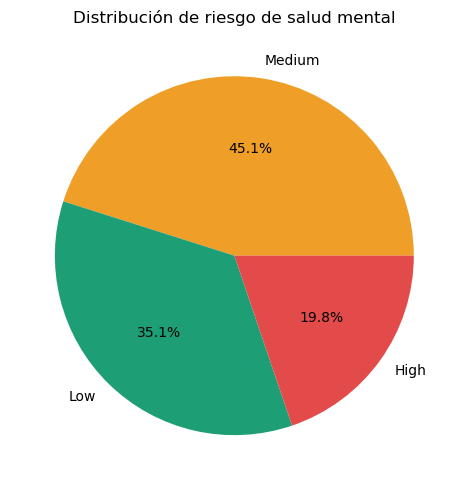

In [22]:
# 2. DISTRIBUCIÓN DE RIESGO
fig, ax = plt.subplots(figsize=(5,5))
df['riesgo_salud_mental'].value_counts().plot.pie(
    autopct='%1.1f%%', ax=ax,
    colors=['#EF9F27','#1D9E75','#E24B4A']
)
ax.set_title('Distribución de riesgo de salud mental')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

OBSERVACIÓN
<p>EL 45.1% de las personas se encuentra en un nivel de riesgo medio, lo que representa el grupo más importante al que se debe prestar atención. Aunque muchas de estas personas aún no presentan problemas graves, es posible que ya esten experimentando señales tempranas de afectación emocional o psicológica. El principal riesgo es que estos casos pasen desapercibidos y no reciban apoyo a tiempo. Como resultado, algunas personas podrían empeorar y pasar a un novel de riesgo alto, donde la atención necesaria suele ser más compleja, prolongada y costosa.</p> 

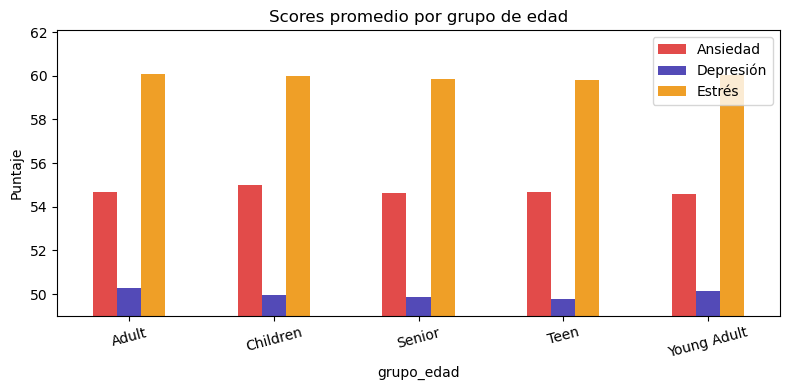

In [28]:
# 3. SCORES POR GRUPO DE EDAD
edad_scores = df.groupby('grupo_edad')[['puntaje_ansiedad','puntaje_depresion','nivel_estres']].mean()
edad_scores.plot(kind='bar', figsize=(8,4), color=['#E24B4A','#534AB7','#EF9F27'])
plt.title('Scores promedio por grupo de edad')
plt.ylabel('Puntaje')
plt.ylim(49, edad_scores.values.max() + 2)  # eje Y desde 49
plt.xticks(rotation=15)
plt.legend(['Ansiedad','Depresión','Estrés'])
plt.tight_layout()
plt.show()

OBSERVACIÓN
<p>El estres es el indicaor más elevado en todos los grupos de edad, con un puntaje cercano a 60 en cada caso. Esto sugiere que el estrés es una condición transversal que afecta por igual a niños, adolecentes, adultso y adultos mayores, independiente de la etapa de vida en la que se encuentren. La ansiedad se manteine de 55 en todos los grupos, mientras que la depresion es el indicador mas bajo rondando los 50 puntos. Se hubiera esperado que los adolecentes y adultos jovenes presenten mayor nivel de ansiedad y depresion que los adultos mayores o los niños.</p>

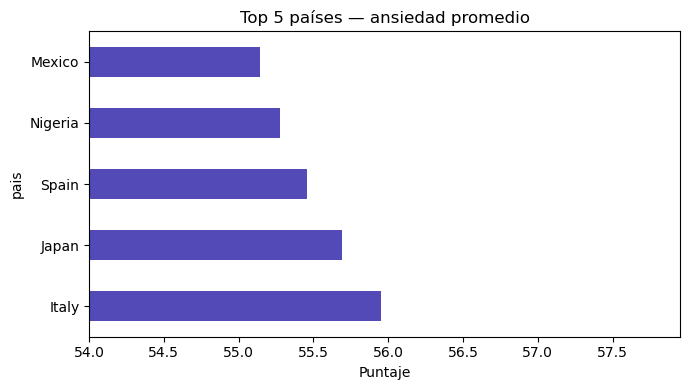

In [30]:
# --- 4. TOP 5 PAÍSES POR ANSIEDAD ---
top_paises = df.groupby('pais')['puntaje_ansiedad'].mean().sort_values(ascending=False).head(5)
top_paises.plot(kind='barh', figsize=(7,4), color='#534AB7')
plt.title('Top 5 países — ansiedad promedio')
plt.xlim(54, top_paises.values.max() + 2)  # eje X desde 49 (barras horizontales)
plt.xlabel('Puntaje')
plt.tight_layout()
plt.show()

OBSERVACIÓN
<p>Italia lidera el ranking con el puntaje de ansiedad más alto, seguido de cerca POR Japón, España, Nigeria y México completan el top 5, con diferencias muy pequeñas entre ellos. Los niveles de ansiedad estan distribuidos de forma uniforme, se esperaria que la diferencia entre ellos variara mucho más por diferentes factores como el sistema de salud, la cultura, el acceso a servicios psicologicos y las condiciones socieconomicas.</p>

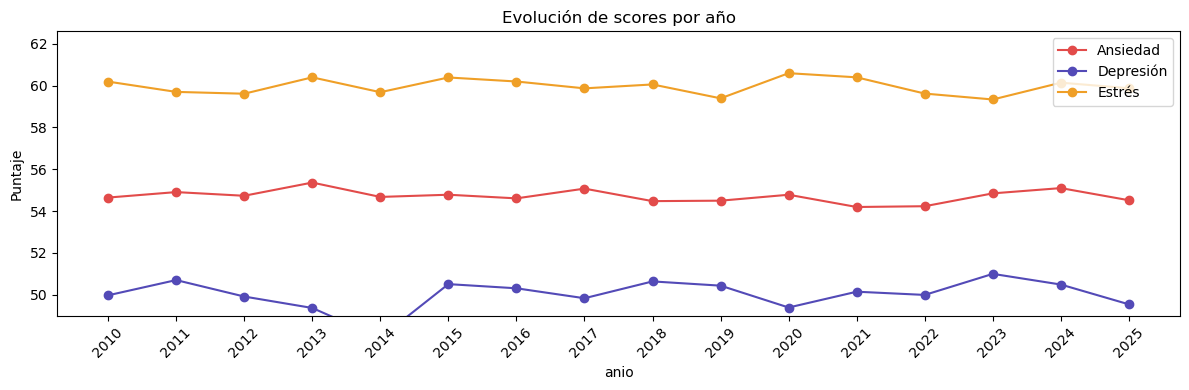

In [31]:
# --- 5. EVOLUCIÓN TEMPORAL POR AÑO (2010-2025) ---
anio_scores = df.groupby('anio')[['puntaje_ansiedad','puntaje_depresion','nivel_estres']].mean()
anio_scores.plot(kind='line', figsize=(12,4), marker='o', color=['#E24B4A','#534AB7','#EF9F27'])
plt.title('Evolución de scores por año')
plt.ylabel('Puntaje')
plt.ylim(49, anio_scores.values.max() + 2)  # eje Y desde 49
plt.xticks(ticks=anio_scores.index, rotation=45)  # marca todos los años
plt.legend(['Ansiedad','Depresión','Estrés'])
plt.tight_layout()
plt.show()

OBSERVACIÓN
<p>Los tres indicadores se mantienen prácticamente constantes durante los 15 años analizados, sin ninguna tendencia clara de aumento o disminución. El estres oscila alrededor de 60, la ansiedad alrededor de 55 y la depresion alrededor de 50, sin que ningún año represente un quiebre o cambio significativo. Lo que se esperaría onserbar es un crecimiento alrededor del 2020, año en que la pandemia de COVID-19 generó un deterioro masivo de la salud mental.  a nivel global.</p>

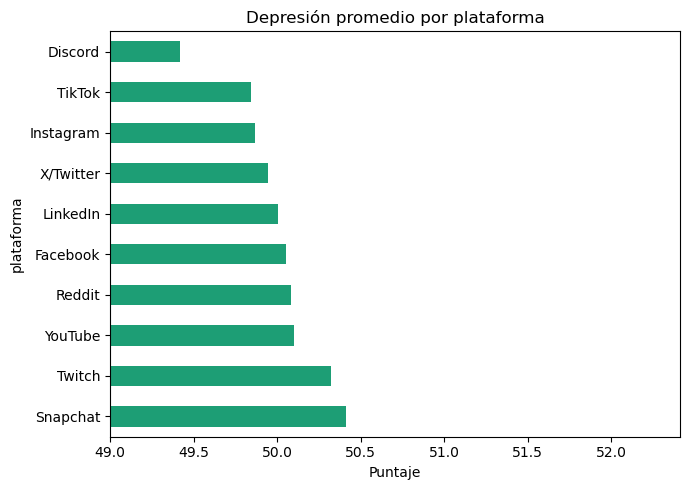

In [35]:
# --- 6. DEPRESIÓN POR PLATAFORMA ---
plat = df.groupby('plataforma')['puntaje_depresion'].mean().sort_values(ascending=False)
plat.plot(kind='barh', figsize=(7,5), color='#1D9E75')
plt.title('Depresión promedio por plataforma')
plt.xlabel('Puntaje')
plt.xlim(49, plat.values.max() + 2)  # eje X desde 40
plt.tight_layout()
plt.show()

OBSERVACIÓN
<p>Snapchat y Twicth presentan los puntajes de depresion más altos, mientras que Discord y Tiktok se ubican en los niveles más bajos. Sin embargo, al igual que en la gráfica de países la diferencia entre la plataforma con mayor puntaje y menor es de paenas 1 puntos sobre una escala de 100 lo que no representa una diferencia significativa.</p>

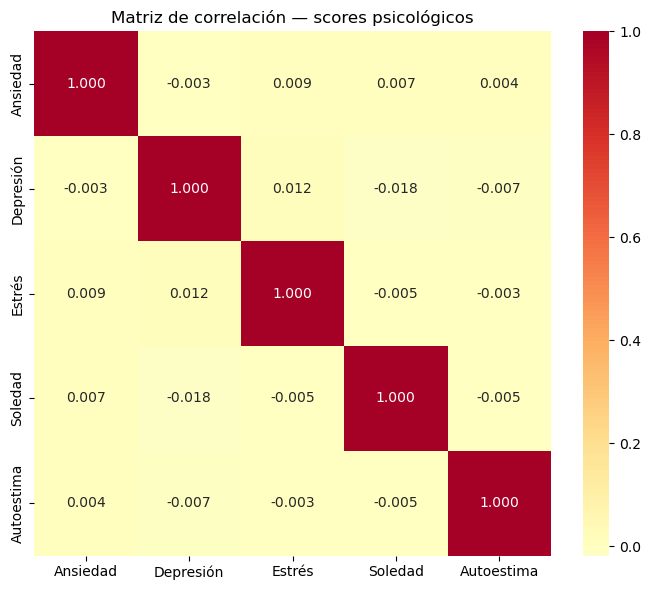

In [27]:
# --- 7. MATRIZ DE CORRELACIÓN ---
corr = df[scores].corr()
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            xticklabels=['Ansiedad','Depresión','Estrés','Soledad','Autoestima'],
            yticklabels=['Ansiedad','Depresión','Estrés','Soledad','Autoestima'],
            ax=ax)
plt.title('Matriz de correlación — scores psicológicos')
plt.tight_layout()
plt.show()

OBSERVACIÓN:

<p>Todos los valores de correlación entre variables se encuentran extremadamente cercanos a cero, lo que indica que no existe ninguna relación lineal entre los cinco indicadores psicologicos analizados. Por lo que conocer el nivel de ansiedad de un paciente no permite predecir en absoluto su nivel de depresion, estres soledad o autoestima. El literatura medica se docuemtna que la ansiedad y la depresion estan correlacionadas fuertemente entre sí. La soledad se asocia a mayores niveles de depresión y que una baja autoestima esta vinculada a mayor ansiedad.</p>